### ReAct Agent Architecture

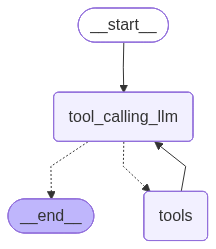

In [5]:
import os
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


load_dotenv()
llm=ChatGroq(model="openai/gpt-oss-120b")

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

tools=[tool,multiply]
llm_with_tool=llm.bind_tools(tools)

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_2949a27f-db4b-49f2-87cc-b7ee48d8c2d2)
 Call ID: fc_2949a27f-db4b-49f2-87cc-b7ee48d8c2d2
  Args:
    query: AI news March 2026
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.commerce.senate.gov/2026/3/less-hype-more-help-ai-that-improves-safety-productivity-and-care", "title": "Less Hype, More Help: AI That Improves Safety, Productivity, and Care", "content": "Witnesses:\n\n   Mr.Demetri Giannikopoulos,Chief Innovation Officer, Rad AI\n   Ms. Brittany Ng,Vice President, Siemens Digital Industries Software\n   Dr. Damion